In [1]:
import cv2 as cv
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator as imgen
from tensorflow.keras import datasets
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Conv2D, MaxPooling2D,Flatten , Dropout,BatchNormalization
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [2]:
data_dir='./dataset/flower_photos'

In [3]:
batch_size=32
img_height=150
img_width=150
BUFFER_SIZE=1000

In [4]:
train_data = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset='training',
    seed=2026,
    image_size=(img_height, img_width),
    batch_size=None
)

val_data = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset='validation',
    seed=2026,
    image_size=(img_height, img_width),
    batch_size=None
)

Found 250 files belonging to 5 classes.
Using 200 files for training.
Found 250 files belonging to 5 classes.
Using 50 files for validation.


In [5]:
# 데이터 증강
def data_augmentaion(image,label):
    image = tf.image.random_flip_left_right(image)
    # image = tf.image.random_up_down(image)
    image = tf.image.random_brightness(image, max_delta=0.3)
    image = tf.image.random_contrast(image, lower=0.8,upper=1.2)
    image = tf.image.random_hue(image,max_delta=0.05)
    image = tf.image.random_saturation(image, lower=0.8, upper=1.2)
    image = tf.cast(image,tf.float32)/255.0
    return image,label

In [6]:
# 정규화
def normalize(image,label):
    image=tf.cast(image,tf.float32)/255.0
    return image,label

In [7]:
train_aug = train_data.map(data_augmentaion, num_parallel_calls = tf.data.AUTOTUNE)
train_aug = train_aug.shuffle(BUFFER_SIZE).batch(batch_size,drop_remainder=True).prefetch(tf.data.AUTOTUNE)

In [8]:
val_aug = val_data.map(normalize, num_parallel_calls=tf.data.AUTOTUNE)
val_aug = val_aug.batch(batch_size,drop_remainder=True).prefetch(tf.data.AUTOTUNE)

In [9]:
class_name = train_data.class_names
print(class_name)

['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


In [10]:
model = Sequential()
model.add(Input(shape=(img_height, img_width, 3)))

model.add(Conv2D(32,3,padding='same',activation='relu'))
model.add(MaxPooling2D())
model.add(Conv2D(64,3,padding='same',activation='relu'))
model.add(MaxPooling2D())
model.add(Conv2D(128,3,padding='same',activation='relu'))
model.add(MaxPooling2D())

model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(5,activation='softmax'))

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 150, 150, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 75, 75, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 75, 75, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 37, 37, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 37, 37, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 18, 18, 128)      0

In [11]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',
             metrics=['accuracy'])

In [12]:
early_stopping = EarlyStopping(monitor='val_loss',patience=20)

history = model.fit(train_aug,validation_data=val_aug,epochs=200,
                   callbacks=[early_stopping])

Epoch 1/200
6/6 [==============================] - 4s 55ms/step - loss: 1.9726 - accuracy: 0.1927 - val_loss: 1.5986 - val_accuracy: 0.2188
Epoch 2/200
6/6 [==============================] - 0s 27ms/step - loss: 1.5294 - accuracy: 0.3542 - val_loss: 1.4443 - val_accuracy: 0.2812
Epoch 3/200
6/6 [==============================] - 0s 25ms/step - loss: 1.3448 - accuracy: 0.3854 - val_loss: 1.4641 - val_accuracy: 0.4688
Epoch 4/200
6/6 [==============================] - 0s 29ms/step - loss: 1.2964 - accuracy: 0.3854 - val_loss: 1.6467 - val_accuracy: 0.4688
Epoch 5/200
6/6 [==============================] - 0s 26ms/step - loss: 1.1749 - accuracy: 0.5000 - val_loss: 1.4075 - val_accuracy: 0.4062
Epoch 6/200
6/6 [==============================] - 0s 26ms/step - loss: 1.2194 - accuracy: 0.5260 - val_loss: 1.3542 - val_accuracy: 0.5000
Epoch 7/200
6/6 [==============================] - 0s 28ms/step - loss: 1.1819 - accuracy: 0.5208 - val_loss: 1.3558 - val_accuracy: 0.5000
Epoch 8/200
6/6 [===

In [13]:
from tensorflow.keras.utils import load_img, img_to_array

In [14]:
path = 'dataset/flower_photos/sunflower.jpg'
img = load_img(path,target_size=(img_height,img_width))
img_array = img_to_array(img,dtype='float32')
img_array = img_array/255.0
img_array = np.expand_dims(img_array,0)

1/1 [==============================] - 0s 118ms/step
예측된 클래스: sunflowers
신뢰도 : 75.16%


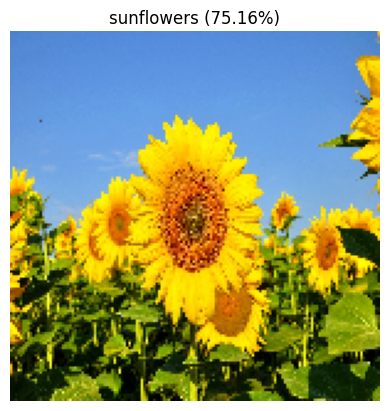

In [15]:
pred = model.predict(img_array)
pred_class = np.argmax(pred[0])

c = np.max(pred[0])*100

print(f'예측된 클래스: {class_name[pred_class]}')
print(f'신뢰도 : {c:.2f}%')
plt.imshow(img)
plt.title(f'{class_name[pred_class]} ({c:.2f}%)')
plt.axis('off')
plt.show()

# 전이 학습
- 이미 학습된 모델을 사용하여 특징 추출 능력이 강함
- 위 프로젝트에선 Google에서 제작된 MoblileNetV2을 사용함 (속도와 정확도 균형에 유용함)

In [16]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(input_shape=(150,150,3),
                        include_top = False,
                        weights = 'imagenet')

base_model.trainable = False

mdoel = Sequential([
    base_model,
    Flatten(),
    BatchNormalization(),
    Dense(128,activation='relu'),
    Dropout(0.5),
    Dense(5,activation='softmax')
])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 150, 150, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 75, 75, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 75, 75, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 37, 37, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 37, 37, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 18, 18, 128)      0

In [17]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',
             metrics=['accuracy'])

In [18]:
early_stopping = EarlyStopping(monitor='val_loss',patience=20, restore_best_weights=True)

history = model.fit(train_aug,validation_data=val_aug,epochs=200,
                   callbacks=[early_stopping])

Epoch 1/200
6/6 [==============================] - 1s 60ms/step - loss: 0.2752 - accuracy: 0.9427 - val_loss: 1.7569 - val_accuracy: 0.5938
Epoch 2/200
6/6 [==============================] - 0s 26ms/step - loss: 0.0716 - accuracy: 0.9792 - val_loss: 2.2366 - val_accuracy: 0.5000
Epoch 3/200
6/6 [==============================] - 0s 28ms/step - loss: 0.1031 - accuracy: 0.9583 - val_loss: 2.3707 - val_accuracy: 0.4062
Epoch 4/200
6/6 [==============================] - 0s 25ms/step - loss: 0.0594 - accuracy: 0.9844 - val_loss: 2.6479 - val_accuracy: 0.5625
Epoch 5/200
6/6 [==============================] - 0s 28ms/step - loss: 0.1521 - accuracy: 0.9427 - val_loss: 1.4486 - val_accuracy: 0.5938
Epoch 6/200
6/6 [==============================] - 0s 26ms/step - loss: 0.0906 - accuracy: 0.9688 - val_loss: 1.7158 - val_accuracy: 0.5000
Epoch 7/200
6/6 [==============================] - 0s 26ms/step - loss: 0.0869 - accuracy: 0.9792 - val_loss: 1.9103 - val_accuracy: 0.5938
Epoch 8/200
6/6 [===

1/1 [==============================] - 0s 35ms/step
예측된 클래스: sunflowers
신뢰도 : 98.62%


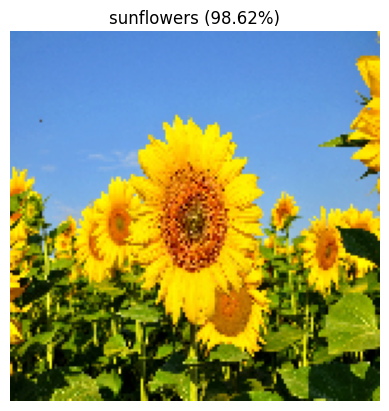

In [19]:
path = 'dataset/flower_photos/sunflower.jpg'
img = load_img(path,target_size=(img_height,img_width))
img_array = img_to_array(img,dtype='float32')
img_array = img_array/255.0
img_array = np.expand_dims(img_array,0)

pred = model.predict(img_array)
pred_class = np.argmax(pred[0])

c = np.max(pred[0])*100

print(f'예측된 클래스: {class_name[pred_class]}')
print(f'신뢰도 : {c:.2f}%')
plt.imshow(img)
plt.title(f'{class_name[pred_class]} ({c:.2f}%)')
plt.axis('off')
plt.show()

1/1 [==============================] - 0s 30ms/step
예측된 클래스: daisy
신뢰도 : 72.02%


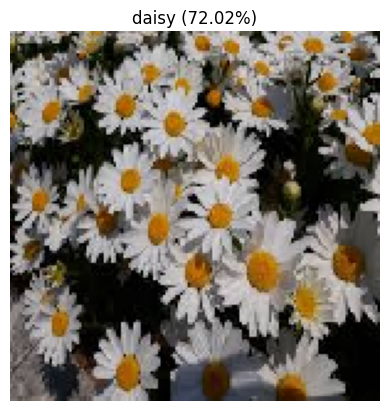

In [20]:
path = 'dataset/flower_photos/daisy.jpg'
img = load_img(path,target_size=(img_height,img_width))
img_array = img_to_array(img,dtype='float32')
img_array = img_array/255.0
img_array = np.expand_dims(img_array,0)

pred = model.predict(img_array)
pred_class = np.argmax(pred[0])

c = np.max(pred[0])*100

print(f'예측된 클래스: {class_name[pred_class]}')
print(f'신뢰도 : {c:.2f}%')
plt.imshow(img)
plt.title(f'{class_name[pred_class]} ({c:.2f}%)')
plt.axis('off')
plt.show()